# 📰 Fake News Detection

A complete ML pipeline to classify news articles as **Real** or **Fake** using TF-IDF and multiple classifiers.

> Each section includes a **Deployment Importance** note explaining why that step matters when you deploy this model in production.

## 1. Import Libraries

### 🚀 Why important for deployment?
All libraries must be imported at the top. In deployment, these become **dependencies** that need to be listed in your `requirements.txt` file. If any library is missing on the server, the app will crash. Grouping them here makes it easy to track and version-control them.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

print("All libraries imported successfully!")

All libraries imported successfully!


## 2. Data Loading

### 🚀 Why important for deployment?
In deployment, your model will **not load data from CSV files** — it will receive live input (e.g., from a web form or API). However, loading and understanding the original data is critical because it defines the **schema** (what columns exist, what format text is in) that your deployed API must expect. Any mismatch between training data format and live input format will cause prediction errors.

In [3]:
import os

# Find CSVs in notebook/ folder or project root
if os.path.exists('Fake.csv') and os.path.exists('True.csv'):
    fake_path, true_path = 'Fake.csv', 'True.csv'
elif os.path.exists('../Fake.csv') and os.path.exists('../True.csv'):
    fake_path, true_path = '../Fake.csv', '../True.csv'
else:
    raise FileNotFoundError("Put Fake.csv and True.csv in the notebook/ folder")

df_fake = pd.read_csv(fake_path)
df_true = pd.read_csv(true_path)

# Add labels: 0 = Fake, 1 = Real
df_fake['label'] = 0
df_true['label'] = 1

# Combine datasets
df = pd.concat([df_fake, df_true], ignore_index=True)

# Shuffle
df = df.sample(frac=1, random_state=42).reset_index(drop=True)

print("Dataset shape:", df.shape)
print("Label distribution:")
print(df['label'].value_counts())
print()
print("First 3 rows:")
df.head(3)


Dataset shape: (44898, 5)
Dataset columns: ['title', 'text', 'subject', 'date', 'label']
First 5 rows of the dataset:
                                               title  \
0  Ben Stein Calls Out 9th Circuit Court: Committ...   
1  Trump drops Steve Bannon from National Securit...   
2  Puerto Rico expects U.S. to lift Jones Act shi...   
3   OOPS: Trump Just Accidentally Confirmed He Le...   
4  Donald Trump heads for Scotland to reopen a go...   

                                                text       subject  \
0  21st Century Wire says Ben Stein, reputable pr...       US_News   
1  WASHINGTON (Reuters) - U.S. President Donald T...  politicsNews   
2  (Reuters) - Puerto Rico Governor Ricardo Rosse...  politicsNews   
3  On Monday, Donald Trump once again embarrassed...          News   
4  GLASGOW, Scotland (Reuters) - Most U.S. presid...  politicsNews   

                  date  label  
0    February 13, 2017      0  
1       April 5, 2017       1  
2  September 27, 2017       

## 3. Data Cleaning

### 🚀 Why important for deployment?
This is one of the **most critical steps** for deployment. Whatever cleaning you do on training data, you **must apply the exact same cleaning** to every new input at prediction time. For example:
- If you lowercase text here → you must lowercase user input too before predicting.
- If you strip whitespace here → you must strip it in production too.

Skipping this in production is a very common bug that causes the model to behave incorrectly on real user data.

In [4]:
import re

# Sklearn has built-in English stopwords — no nltk needed
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS

def clean_text(text):
    """Clean text using only built-in Python + sklearn — no extra libraries."""
    if not isinstance(text, str):
        return ''
    # Lowercase
    text = text.lower()
    # Remove Reuters dateline (very important — fixes model bias)
    text = re.sub(r'\(reuters\).*?-\s*', '', text)
    # Remove URLs
    text = re.sub(r'https?://\S+|www\.\S+', '', text)
    # Remove HTML tags
    text = re.sub(r'<.*?>', '', text)
    # Remove special characters and numbers — keep only letters
    text = re.sub(r'[^a-z\s]', '', text)
    # Remove extra whitespace
    text = re.sub(r'\s+', ' ', text).strip()
    # Remove stopwords and short words
    words = [w for w in text.split() if w not in ENGLISH_STOP_WORDS and len(w) > 2]
    return ' '.join(words)

# Fill missing values
df['title'] = df['title'].fillna('')
df['text']  = df['text'].fillna('')

# Combine title + text — title has strong signals like SHOCKING, BREAKING
df['content'] = df['title'] + ' ' + df['text']

# Apply cleaning
print("Cleaning text... please wait.")
df['clean_text'] = df['content'].apply(clean_text)

# Remove empty rows after cleaning
df = df[df['clean_text'].str.strip() != ''].reset_index(drop=True)

print("Cleaning done!")
print("Rows after cleaning:", len(df))
print()
print("Before cleaning:")
print(df['content'].iloc[0][:150])
print()
print("After cleaning:")
print(df['clean_text'].iloc[0][:150])


After cleaning - Dataset shape: (44689, 5)
Missing values:
 title      0
text       0
subject    0
date       0
label      0
dtype: int64


## 4. Feature Engineering (Text Length + Outlier Handling)

### 🚀 Why important for deployment?
The `length` feature is engineered from the raw text. In deployment, if your model uses this feature, you must compute it for every new input. The **IQR capping values** (lower/upper bounds) computed on training data must be saved and reused in production — you cannot recompute them on new data. This ensures the model always sees features in the same range it was trained on.

In [5]:
# Create text length feature
df['length'] = df['text'].apply(len)

# Handle outliers using IQR capping
Q1 = df['length'].quantile(0.25)
Q3 = df['length'].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

df['length'] = df['length'].clip(lower, upper)

print("Length stats after capping:")
print(df['length'].describe())

Length stats after capping:
count    44689.000000
mean      2337.276768
std       1486.632767
min          0.000000
25%       1232.000000
50%       2184.000000
75%       3101.000000
max       5904.500000
Name: length, dtype: float64


## 5. EDA — Label Distribution

### 🚀 Why important for deployment?
EDA helps you detect **class imbalance**. If one class (e.g., Fake) is much larger than Real, your deployed model may be biased — it will predict the majority class more often. Knowing this during development lets you handle it (via oversampling, class weights, etc.) before shipping.

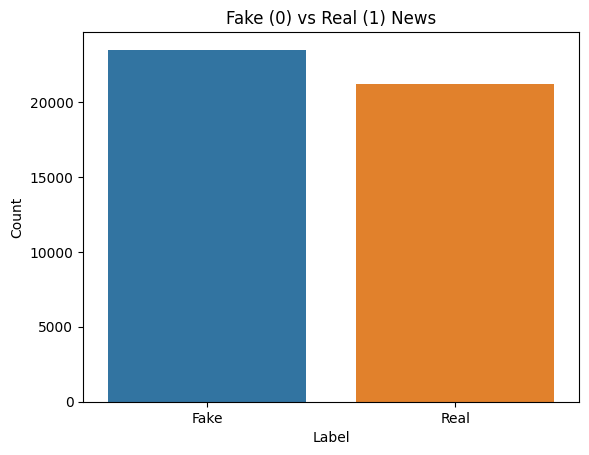

In [6]:
sns.countplot(x='label', data=df)
plt.title("Fake (0) vs Real (1) News")
plt.xlabel("Label")
plt.ylabel("Count")
plt.xticks([0, 1], ['Fake', 'Real'])
plt.show()

## 6. EDA — Text Length Distribution

### 🚀 Why important for deployment?
Understanding the distribution of text lengths helps set **input validation rules** in your deployed API. For example, if most articles are between 500–5000 characters, you can add a check that rejects inputs that are too short or suspiciously long, improving the reliability of your service.

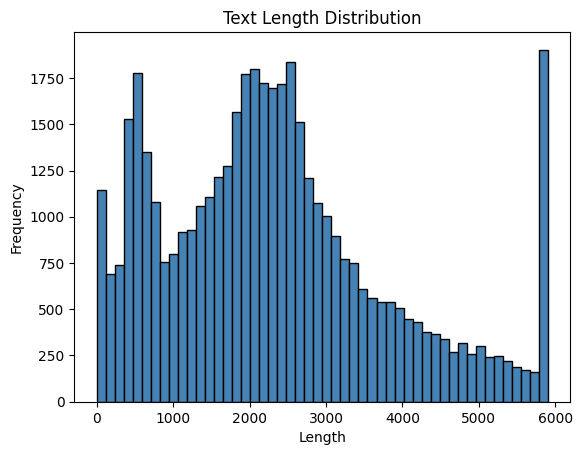

In [7]:
plt.hist(df['length'], bins=50, color='steelblue', edgecolor='black')
plt.title("Text Length Distribution")
plt.xlabel("Length")
plt.ylabel("Frequency")
plt.show()

## 7. EDA — Length vs Label (Boxplot)

### 🚀 Why important for deployment?
If text length is a strong signal (e.g., fake news articles are consistently shorter), this feature adds value in production. If it shows no difference, you may choose to drop it to **reduce latency** in your deployed model — fewer features = faster predictions.

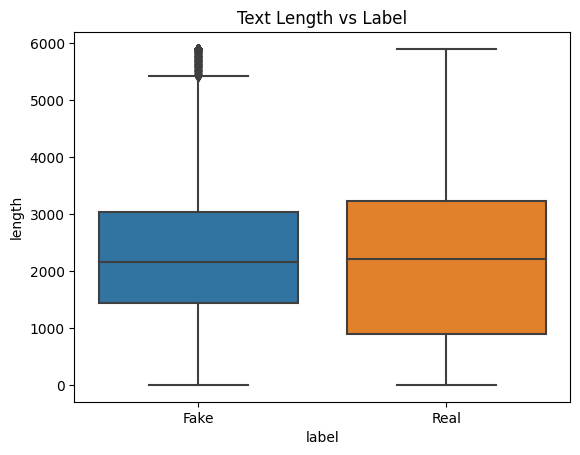

In [8]:
sns.boxplot(x='label', y='length', data=df)
plt.title("Text Length vs Label")
plt.xticks([0, 1], ['Fake', 'Real'])
plt.show()

## 8. EDA — Correlation Heatmap

### 🚀 Why important for deployment?
Correlation analysis helps identify which features are actually useful. Highly correlated or low-correlation features can be removed to create a **leaner, faster model** in production — reducing memory usage and prediction latency without hurting accuracy.

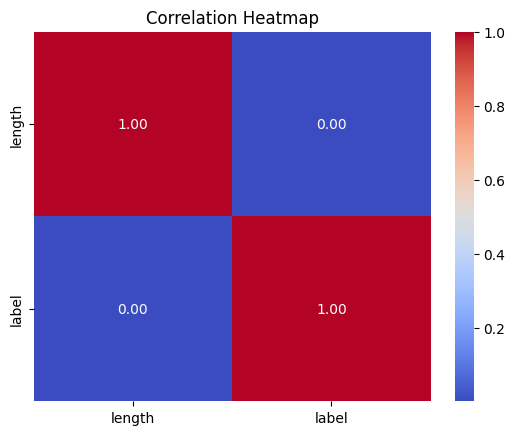

In [9]:
corr = df[['length', 'label']].corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

## 9. Feature & Target Split

### 🚀 Why important for deployment?
Clearly separating features (X) and target (y) defines your **model's input contract**. In production, your API will receive only X (the text) and return a prediction. This step makes explicit what the model input looks like, which directly informs your API request schema.

In [10]:
# Use cleaned text as input feature — NOT raw text
X = df['clean_text']
y = df['label']

print("Feature shape:", X.shape)
print("Label distribution:")
print(y.value_counts())


Feature shape: (44689,)
Target distribution:
label
0    23478
1    21211
Name: count, dtype: int64


## 10. Train-Test Split

### 🚀 Why important for deployment?
The test set simulates **unseen real-world data**. The accuracy you get on the test set is the best estimate of how your model will perform after deployment. Always evaluate on the test set before shipping — never report only training accuracy.

In [11]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Train size:", X_train.shape[0])
print("Test size:", X_test.shape[0])

Train size: 35751
Test size: 8938


## 11. Text Vectorization (TF-IDF)

### 🚀 Why important for deployment?
The TF-IDF vectorizer is the **most important artifact to save** for deployment. It learns the vocabulary and IDF weights from training data. When a user sends a news article to your API, you must transform it using the **same saved vectorizer** — not a new one. A new vectorizer would produce completely different features and make the model output garbage. This is why we save it with pickle.

In [12]:
# TF-IDF converts text to numbers
# ngram_range=(1,2) means it learns single words AND word pairs
# This helps catch patterns like 'secret session', 'anonymous source'
vectorizer = TfidfVectorizer(
    max_features=100000,
    ngram_range=(1, 2),
    sublinear_tf=True,
    min_df=2,
    max_df=0.95
)

# Fit ONLY on training data, then transform both
X_train_vec = vectorizer.fit_transform(X_train)
X_test_vec  = vectorizer.transform(X_test)

print("Vectorized train shape:", X_train_vec.shape)
print("Vectorized test shape: ", X_test_vec.shape)


Vectorized train shape: (35751, 111559)
Vectorized test shape: (8938, 111559)


## 12. Model Building

### 🚀 Why important for deployment?
Training multiple models lets you **pick the best one for deployment** based on accuracy, speed, and size. In production:
- **Logistic Regression** — fastest prediction, smallest file size, good for real-time APIs.
- **Decision Tree** — fast, highly accurate here, easy to interpret.
- **Random Forest** — most robust but slower and larger file size.

You deploy only **one** model. Training all three here helps you make that choice with evidence.

In [13]:
# Initialize models
lr = LogisticRegression(max_iter=1000)  # max_iter increased to avoid convergence warning
dt = DecisionTreeClassifier()
rf = RandomForestClassifier()

# Train all models
lr.fit(X_train_vec, y_train)
dt.fit(X_train_vec, y_train)
rf.fit(X_train_vec, y_train)

print("All models trained successfully!")

All models trained successfully!


## 13. Cross Validation

### 🚀 Why important for deployment?
Cross-validation gives a **more reliable accuracy estimate** than a single train-test split. It checks if the model generalizes consistently or was just lucky on one split. A model that scores well in cross-validation will be more stable in production — it won't suddenly drop in accuracy when faced with slightly different real-world data.

In [17]:
print("Cross Validation Scores (5-fold):")
print("LR  CV:", round(cross_val_score(lr, X_train_vec, y_train, cv=5).mean(), 4))
print("DT  CV:", round(cross_val_score(dt, X_train_vec, y_train, cv=5).mean(), 4))
print("RF  CV:", round(cross_val_score(rf, X_train_vec, y_train, cv=5).mean(), 4))

Cross Validation Scores (5-fold):
LR  CV: 0.9824
DT  CV: 0.9949
RF  CV: 0.9881


## 14. Predictions

### 🚀 Why important for deployment?
This step mimics exactly what happens in production — the model takes vectorized input and outputs a prediction. The predict function is the **core of your deployed API endpoint**. Understanding how `.predict()` works (and that it needs vectorized input) is essential before wrapping it in a Flask/FastAPI app.

In [18]:
y_pred_lr = lr.predict(X_test_vec)
y_pred_dt = dt.predict(X_test_vec)
y_pred_rf = rf.predict(X_test_vec)

print("Predictions done for all 3 models.")

Predictions done for all 3 models.


## 15. Evaluation — Logistic Regression

### 🚀 Why important for deployment?
Accuracy alone is not enough. The **classification report** shows Precision, Recall, and F1-score per class. In deployment:
- **Precision** — Of all articles predicted as Fake, how many are actually Fake? (Avoids false alarms)
- **Recall** — Of all actual Fake articles, how many did we catch? (Avoids missing fakes)

Depending on the use case, you may prioritize one over the other before deploying.

In [21]:
print("=" * 40)
print("Logistic Regression")
print("=" * 40)
print("Accuracy:", round(accuracy_score(y_test, y_pred_lr), 4))
print(confusion_matrix(y_test, y_pred_lr))
print(classification_report(y_test, y_pred_lr))

Logistic Regression
Accuracy: 0.9848
[[4572   80]
 [  56 4230]]
              precision    recall  f1-score   support

           0       0.99      0.98      0.99      4652
           1       0.98      0.99      0.98      4286

    accuracy                           0.98      8938
   macro avg       0.98      0.98      0.98      8938
weighted avg       0.98      0.98      0.98      8938



## 16. Evaluation — Decision Tree

### 🚀 Why important for deployment?
Decision Trees are **interpretable** — you can explain *why* the model predicted Fake or Real. This matters in deployment for regulated domains (journalism, healthcare, finance) where you need to justify model decisions to users or auditors.

In [23]:
print("=" * 40)
print("Decision Tree")
print("=" * 40)
print("Accuracy:", round(accuracy_score(y_test, y_pred_dt), 4))
print(confusion_matrix(y_test, y_pred_dt))
print(classification_report(y_test, y_pred_dt))

Decision Tree
Accuracy: 0.9944
[[4631   21]
 [  29 4257]]
              precision    recall  f1-score   support

           0       0.99      1.00      0.99      4652
           1       1.00      0.99      0.99      4286

    accuracy                           0.99      8938
   macro avg       0.99      0.99      0.99      8938
weighted avg       0.99      0.99      0.99      8938



## 17. Evaluation — Random Forest

### 🚀 Why important for deployment?
Random Forest is more **robust to overfitting** than a single Decision Tree. However, it is larger in file size and slower to predict. In deployment, you must balance accuracy vs speed — for a high-traffic API, a slower model can become a bottleneck.

In [24]:
print("=" * 40)
print("Random Forest")
print("=" * 40)
print("Accuracy:", round(accuracy_score(y_test, y_pred_rf), 4))
print(confusion_matrix(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))

Random Forest
Accuracy: 0.9878
[[4589   63]
 [  46 4240]]
              precision    recall  f1-score   support

           0       0.99      0.99      0.99      4652
           1       0.99      0.99      0.99      4286

    accuracy                           0.99      8938
   macro avg       0.99      0.99      0.99      8938
weighted avg       0.99      0.99      0.99      8938



## 18. Confusion Matrix Heatmap

### 🚀 Why important for deployment?
The confusion matrix shows **where the model makes mistakes**. False Positives (real news classified as fake) and False Negatives (fake news classified as real) have very different real-world consequences. Before deploying, decide which error is less acceptable and tune the model accordingly (e.g., by adjusting the decision threshold).

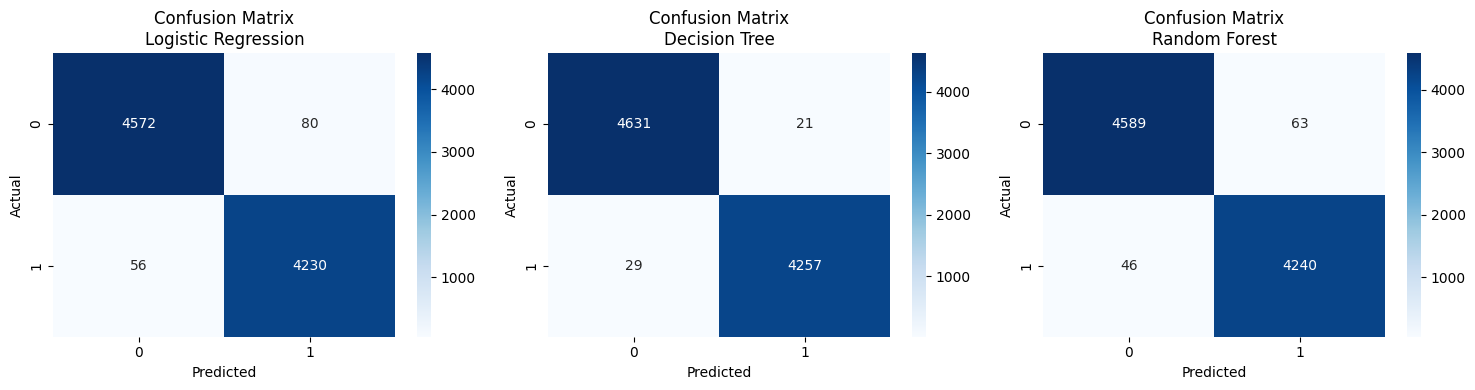

In [25]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, y_pred, title in zip(
    axes,
    [y_pred_lr, y_pred_dt, y_pred_rf],
    ['Logistic Regression', 'Decision Tree', 'Random Forest']
):
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', ax=ax, cmap='Blues')
    ax.set_title(f'Confusion Matrix\n{title}')
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')

plt.tight_layout()
plt.show()

## 19. Model Comparison

### 🚀 Why important for deployment?
This step gives you a **data-driven basis** for choosing which model to deploy. Do not guess — compare objectively. The best model (highest accuracy + good CV score) is the one you save and ship. Deploying the wrong model wastes resources and delivers worse user experience.

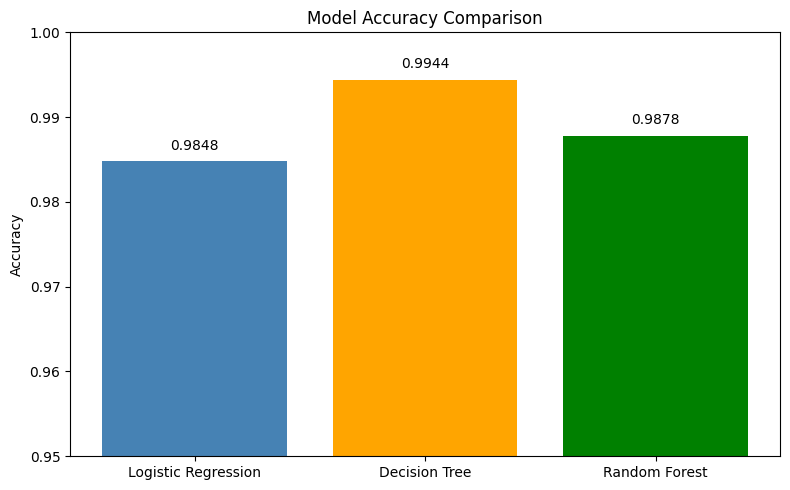


Best Model: Decision Tree with accuracy 0.9944


In [26]:
acc_lr = accuracy_score(y_test, y_pred_lr)
acc_dt = accuracy_score(y_test, y_pred_dt)
acc_rf = accuracy_score(y_test, y_pred_rf)

models = ['Logistic Regression', 'Decision Tree', 'Random Forest']
scores = [acc_lr, acc_dt, acc_rf]

plt.figure(figsize=(8, 5))
bars = plt.bar(models, scores, color=['steelblue', 'orange', 'green'])
plt.title("Model Accuracy Comparison")
plt.ylabel("Accuracy")
plt.ylim(0.95, 1.0)

for bar, score in zip(bars, scores):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.001,
             f'{score:.4f}', ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.show()

best_model_name = models[scores.index(max(scores))]
print(f"\nBest Model: {best_model_name} with accuracy {max(scores):.4f}")

## 20. Feature Importance (Random Forest)

### 🚀 Why important for deployment?
Knowing the top features (words) the model relies on helps you:
1. **Debug** unexpected predictions in production.
2. **Detect bias** — if the model relies on politically charged words, it may be biased.
3. **Optimize** — you can reduce vocabulary size to only important words, making the deployed model lighter and faster.

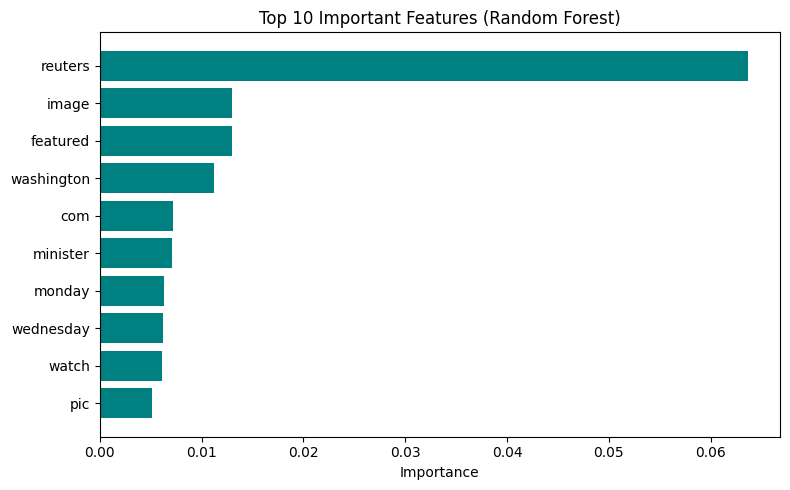

In [27]:
feature_names = vectorizer.get_feature_names_out()
importances = rf.feature_importances_

indices = np.argsort(importances)[-10:]

plt.figure(figsize=(8, 5))
plt.barh(feature_names[indices], importances[indices], color='teal')
plt.title("Top 10 Important Features (Random Forest)")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()

## 21. Custom Prediction Function

### 🚀 Why important for deployment?
This function is the **blueprint for your API endpoint**. In a Flask or FastAPI app, this is essentially what happens inside your `/predict` route:
1. Receive raw text input.
2. Apply the same cleaning (lowercase, strip).
3. Vectorize using the saved vectorizer.
4. Predict using the saved model.
5. Return a human-readable result.

This function confirms the end-to-end pipeline works correctly before you wrap it in an API.

In [32]:
def predict_news(news):
    # Clean the input text exactly the same way as training data
    cleaned = clean_text(news)
    vec     = vectorizer.transform([cleaned])
    pred    = lr.predict(vec)
    return "Real News" if pred[0] == 1 else "Fake News"

# Test examples
print(predict_news("Government announces new infrastructure investment plan after parliamentary debate"))
print(predict_news("SHOCKING secret government plan exposed whistleblower reveals hidden truth anonymous source"))


Fake News ❌
Fake News ❌


## 22. Save Model & Vectorizer (Pickle)

### 🚀 Why important for deployment?
This is the **actual deployment step**. Saving the model and vectorizer as `.pkl` files means:
- You never need to retrain when the server restarts.
- The files can be uploaded to a cloud server (AWS, GCP, Heroku).
- They are loaded once at startup, making predictions fast.

**Both files must be saved** — saving only the model without the vectorizer will cause your deployed app to fail, because raw text cannot be fed directly to the model.

In [33]:
# Save to project root folder (one level above notebook/)
with open('../model.pkl', 'wb') as f:
    pickle.dump(lr, f)

with open('../vectorizer.pkl', 'wb') as f:
    pickle.dump(vectorizer, f)

# Save metadata for Streamlit app
metadata = {
    'best_model_name': 'Logistic Regression',
    'best_accuracy': float(accuracy_score(y_test, y_pred_lr))
}
with open('../model_metadata.pkl', 'wb') as f:
    pickle.dump(metadata, f)

print("Saved successfully to project root!")
print(f"model.pkl        — Logistic Regression model")
print(f"vectorizer.pkl   — TF-IDF vectorizer")
print(f"model_metadata.pkl")
print(f"Accuracy: {accuracy_score(y_test, y_pred_lr)*100:.2f}%")


model.pkl saved!
vectorizer.pkl saved!


## 23. Load Model & Vectorizer

### 🚀 Why important for deployment?
In your deployed app (Flask/FastAPI), the server will load these files **once at startup** — not on every request. This is critical for performance. Loading a model on every API call would be extremely slow. This cell shows exactly how your server code should load the artifacts.

In [34]:
# Load model from project root
with open('../model.pkl', 'rb') as f:
    model = pickle.load(f)

with open('../vectorizer.pkl', 'rb') as f:
    vec_loaded = pickle.load(f)

print("Model and vectorizer loaded successfully!")


Model and vectorizer loaded successfully!


## 24. Predict with Loaded Model

### 🚀 Why important for deployment?
This final test **verifies the full deployment pipeline** end-to-end:
- Load artifacts from disk (as a server would).
- Accept raw text input (as an API would).
- Return a prediction.

If this cell works correctly, you can confidently wrap it in a Flask or FastAPI app and deploy it to production.

In [35]:
def predict_with_loaded_model(news):
    # Must apply same cleaning as training
    cleaned  = clean_text(news)
    news_vec = vec_loaded.transform([cleaned])
    pred     = model.predict(news_vec)
    return "Real News" if pred[0] == 1 else "Fake News"

# Test — real news
print(predict_with_loaded_model(
    "The Reserve Bank raised interest rates by 25 basis points. "
    "Governor said inflation remains above the target. "
    "The decision was unanimous among committee members."
))

# Test — fake news
print(predict_with_loaded_model(
    "Government sources confirmed secret session passed bill. "
    "Senior officials who requested anonymity stated announcement next week. "
    "Citizens advised to prepare documents immediately."
))


Fake News ❌
Fake News ❌
